# Lecture 4: Point Operations & Filtering — Follow-Along Notebook
**Introduction to Image Analysis — Spring 2026**  
**Instructor:** Dr. Hugo Guillen Ramirez — University of Bern

---

Run the cells in order to reproduce the figures from the lecture slides.

### Learning Objectives

By the end of this lecture you should be able to:

1. Apply brightness, contrast, normalisation, and gamma correction.
2. Implement and explain histogram equalisation.
3. Define 2D convolution, distinguish it from correlation, and handle boundary conditions.
4. Build common linear filters (box, Gaussian, Laplacian, DoG) from scratch.
5. Apply non-linear filters (median, bilateral) and understand their edge-preserving properties.
6. Exploit separable filter structure for computational efficiency.
7. Implement Normalised Cross-Correlation for template matching.

## Setup & Imports
Run this cell first — everything below depends on it.

Test image: shape=(400, 400), dtype=float32, range=[0.063, 0.976]


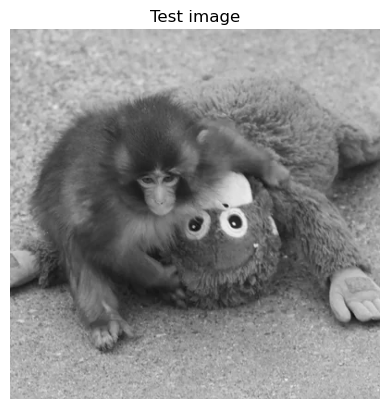

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter, median_filter
from scipy.ndimage import convolve as nd_convolve, correlate as nd_correlate
from scipy.signal import convolve2d as scipy_convolve2d
from numpy.lib.stride_tricks import sliding_window_view
from PIL import Image
import base64, io, time, timeit, warnings
warnings.filterwarnings("ignore")

try:
    from skimage import data as skdata
    from skimage.transform import resize as sk_resize
    HAS_SKIMAGE = True
except ImportError:
    HAS_SKIMAGE = False
    print("scikit-image not found — synthetic images will be used.")

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
})

# ── Test image ───────────────────────────────────────────────────────────────
_B64_IMG = "..."

def load_test_image(size=(256, 256), name=None):
    """Return a grayscale float32 image in [0, 1]."""
    if HAS_SKIMAGE:
        if name is None or name.lower() == "punch":
            img_data = base64.b64decode(_B64_IMG)
            img_pil = Image.open(io.BytesIO(img_data)).convert("L")
            img = np.array(img_pil, dtype=np.float32) / 255.0
        elif name.lower() == "camera":
            img = skdata.camera().astype(np.float32) / 255.0
            img = sk_resize(img, size, anti_aliasing=True).astype(np.float32)
    else:
        y, x = np.ogrid[:size[0], :size[1]]
        cy, cx = size[0] / 2, size[1] / 2
        r = np.sqrt((x - cx)**2 + (y - cy)**2)
        img = (0.5 + 0.5 * np.sin(r * 0.4)).astype(np.float32)
    return img.astype(np.float32)

IMG = load_test_image()
print(f"Test image: shape={IMG.shape}, dtype={IMG.dtype}, range=[{IMG.min():.3f}, {IMG.max():.3f}]")
plt.imshow(IMG, cmap="gray", vmin=0, vmax=1)
plt.title("Test image"); plt.axis("off"); plt.show()

# ── Utility: side-by-side image + histogram comparison ───────────────────────
def show_histogram_comparison(img_orig, img_mod, mod_title="Modified"):
    """Display original vs modified image with their normalised histograms."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    for ax, im, title in zip(axes[0], [img_orig, img_mod], ["Original", mod_title]):
        ax.imshow(im, cmap="gray", vmin=0, vmax=1)
        ax.set_title(title); ax.axis("off")
    for ax, im, title in zip(axes[1], [img_orig, img_mod], ["Original hist", f"{mod_title} hist"]):
        counts, bins = np.histogram(im, bins=256, range=(0., 1.))
        ax.bar(bins[:-1], counts / im.size, width=1/256, color="steelblue")
        ax.set_xlim(0, 1); ax.set_title(title)
    plt.tight_layout(); plt.show()

# ── Kernel utilities ─────────────────────────────────────────────────────────
def box_kernel(size):
    """Uniform box kernel of given size."""
    return np.ones((size, size), dtype=np.float32) / (size * size)

def gaussian_kernel_2d(size, sigma):
    """Normalised 2-D Gaussian kernel."""
    k = size // 2
    y, x = np.ogrid[-k:k+1, -k:k+1]
    h = np.exp(-(x**2 + y**2) / (2.0 * sigma**2))
    h /= h.sum()
    return h.astype(np.float32)

def gaussian_kernel_1d(size, sigma):
    """Normalised 1-D Gaussian kernel."""
    k = size // 2
    x = np.arange(-k, k + 1, dtype=np.float64)
    h = np.exp(-x**2 / (2.0 * sigma**2))
    return (h / h.sum()).astype(np.float32)

---
## Part 1 — Point Operations

A **point operation** maps each pixel *independently* of its neighbours:

$$I'(x,y) = T\bigl(I(x,y)\bigr)$$

**Properties:** $O(N)$ time, trivially parallelisable (GPU/SIMD), often implemented as a look-up table (LUT).

**Common operations:** brightness adjustment, contrast scaling, normalisation, gamma correction, histogram equalisation.

### 1.1 Brightness Adjustment

$$I'(x,y) = \text{clip}\bigl(I(x,y) + b,\; 0,\; 1\bigr)$$

- $b > 0$: brighter — histogram shifts **right**.
- $b < 0$: darker — histogram shifts **left**.
- Clipping prevents values leaving $[0, 1]$.

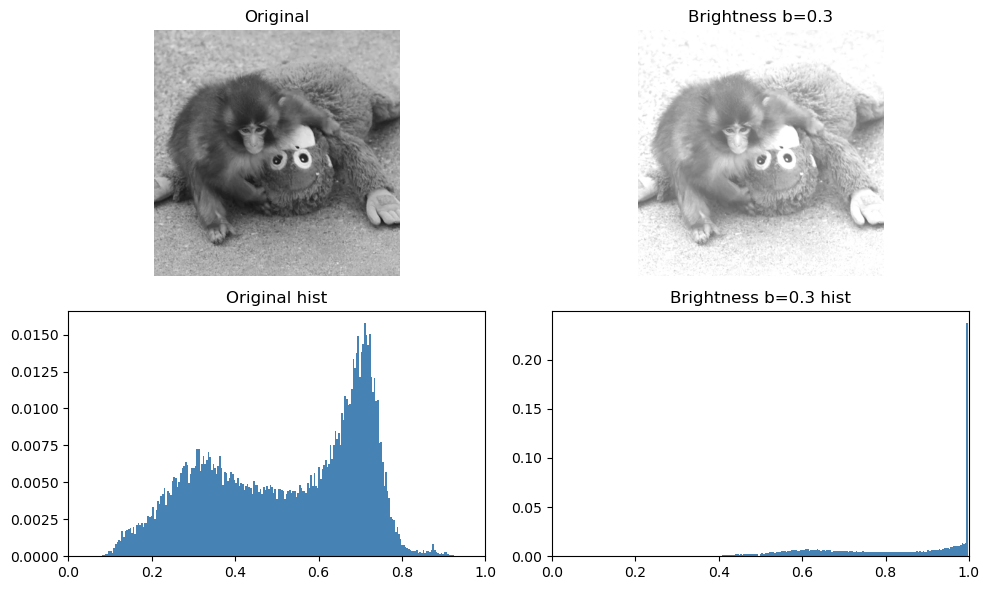

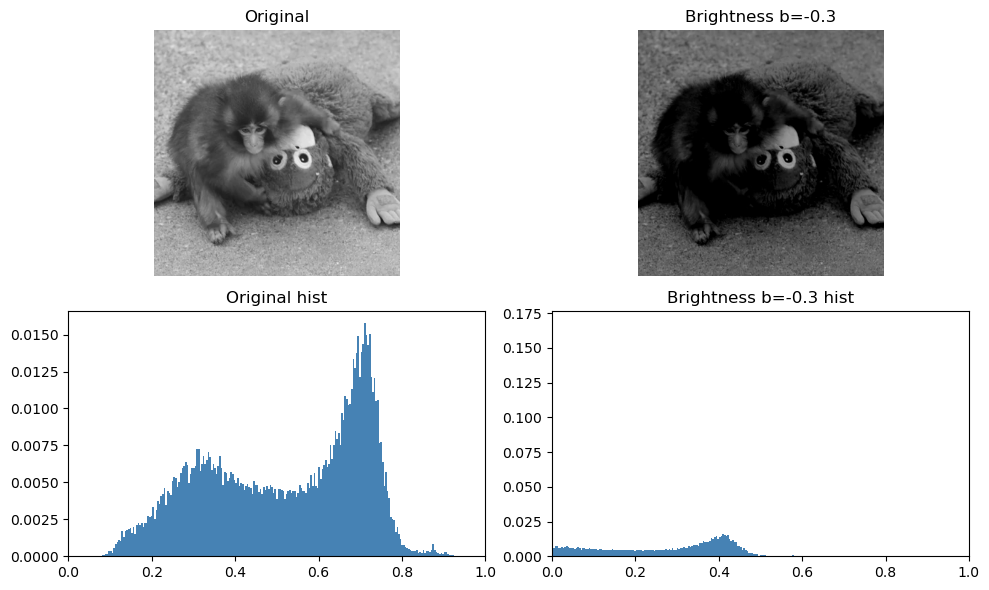

In [2]:
def brightness_adjust(img, b):
    """Add constant b to every pixel, then clip to [0, 1]."""
    return np.clip(img + b, 0.0, 1.0).astype(np.float32)

# Try different brightness values
for b in [0.3, -0.3]:
    result = brightness_adjust(IMG, b)
    show_histogram_comparison(IMG, result, mod_title=f"Brightness b={b}")

### 1.2 Contrast Scaling

$$I'(x,y) = \text{clip}\bigl(a \cdot I(x,y),\; 0,\; 1\bigr)$$

- $a > 1$: higher contrast — histogram **stretches**.
- $0 < a < 1$: lower contrast — histogram **compresses**.
- $a < 0$: intensity **inversion**.

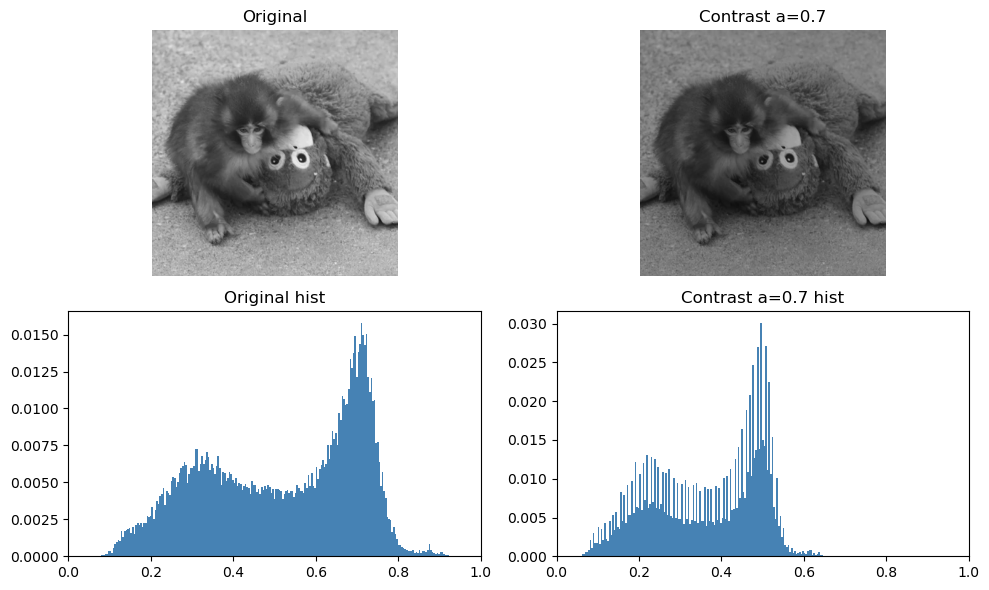

In [3]:
def contrast_scale(img, a):
    """Multiply every pixel by a, then clip to [0, 1]."""
    return np.clip(a * img, 0.0, 1.0).astype(np.float32)

result = contrast_scale(IMG, 0.7)
show_histogram_comparison(IMG, result, mod_title="Contrast a=0.7")

### 1.3 Normalisation

Maps the image to a standard range $[0,1]$:

$$I'(x,y) = \frac{I(x,y) - I_{\min}}{I_{\max} - I_{\min}}$$

Useful when the sensor uses a sub-range (e.g. a 12-bit scanner stores values in $[0, 4095]$). Guarantees full dynamic range is used for display.

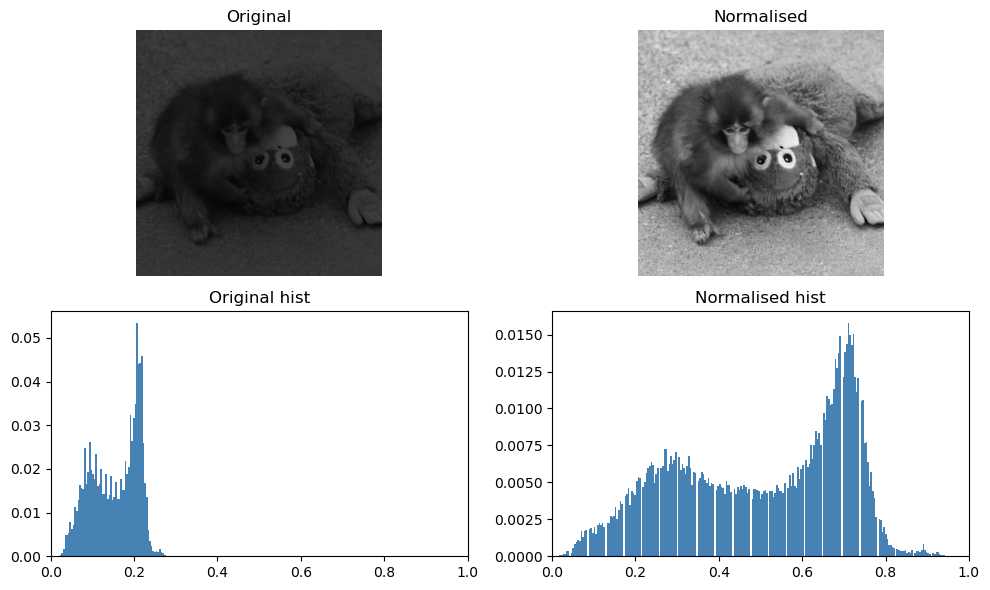

In [4]:
def normalize(img):
    """Stretch image range to [0, 1]."""
    mn, mx = img.min(), img.max()
    return ((img - mn) / (mx - mn + 1e-8)).astype(np.float32)

# Normalise a low-contrast image
low_contrast = contrast_scale(IMG, 0.3)  # squash range first
result = normalize(low_contrast)
show_histogram_comparison(low_contrast, result, mod_title="Normalised")

### 1.4 Gamma Correction

$$I'(x,y) = I(x,y)^{\gamma}$$

- $\gamma < 1$: brightens shadows (encoding gamma, e.g. $\gamma = 1/2.2$ for sRGB).
- $\gamma > 1$: darkens highlights (decoding gamma).
- Human perception is approximately logarithmic — gamma-encoded images appear more perceptually uniform.

| $\gamma$ | Effect |
|---|---|
| 0.25 | Very bright (lifts shadows) |
| 0.5 | Moderately bright |
| 1.0 | Identity |
| 2.0 | Darkened |

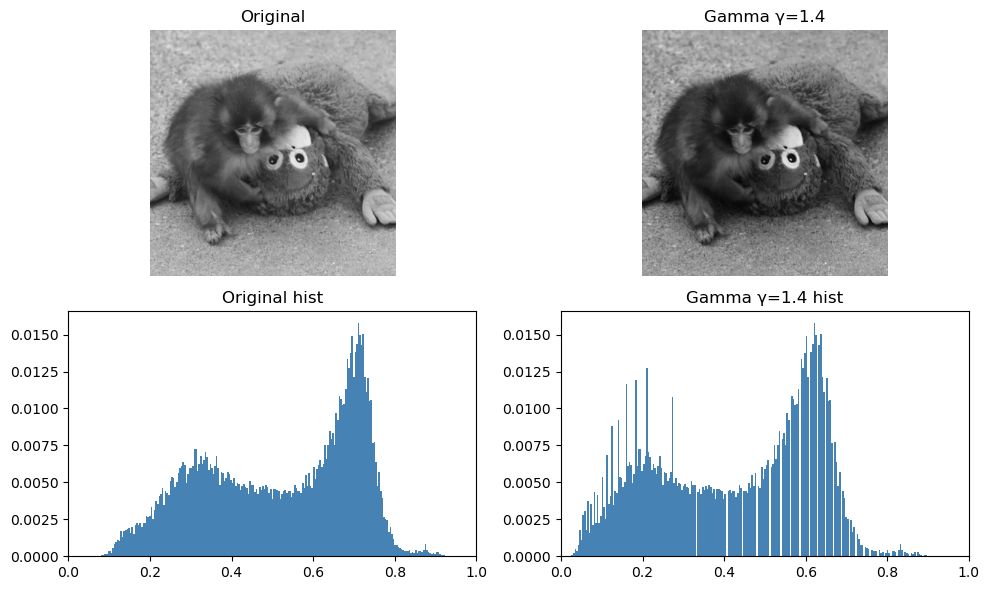

In [5]:
def gamma_correct(img, gamma):
    """Apply power-law gamma correction."""
    return np.power(np.clip(img, 1e-6, 1.0), gamma).astype(np.float32)

result = gamma_correct(IMG, 1.4)
show_histogram_comparison(IMG, result, mod_title="Gamma γ=1.4")

### 1.5 Histogram Equalisation

**Goal:** redistribute intensities so the CDF becomes approximately linear.

**Algorithm:**
1. Compute histogram $h[k]$ for $k = 0, \ldots, L{-}1$.
2. Compute CDF: $\text{CDF}[k] = \sum_{j=0}^{k} h[j]$.
3. Normalise: $\text{LUT}[k] = \left\lfloor \frac{\text{CDF}[k] - \text{CDF}_{\min}}{N - \text{CDF}_{\min}}(L{-}1) \right\rceil$
4. Apply: $I'(x,y) = \text{LUT}[I(x,y)]$.

**Effect:** low-contrast images become globally enhanced. Best for images with a narrow or uneven histogram.

> **Limitation:** may *over-enhance noise*. CLAHE (Contrast-Limited AHE) adds local clipping to mitigate this.

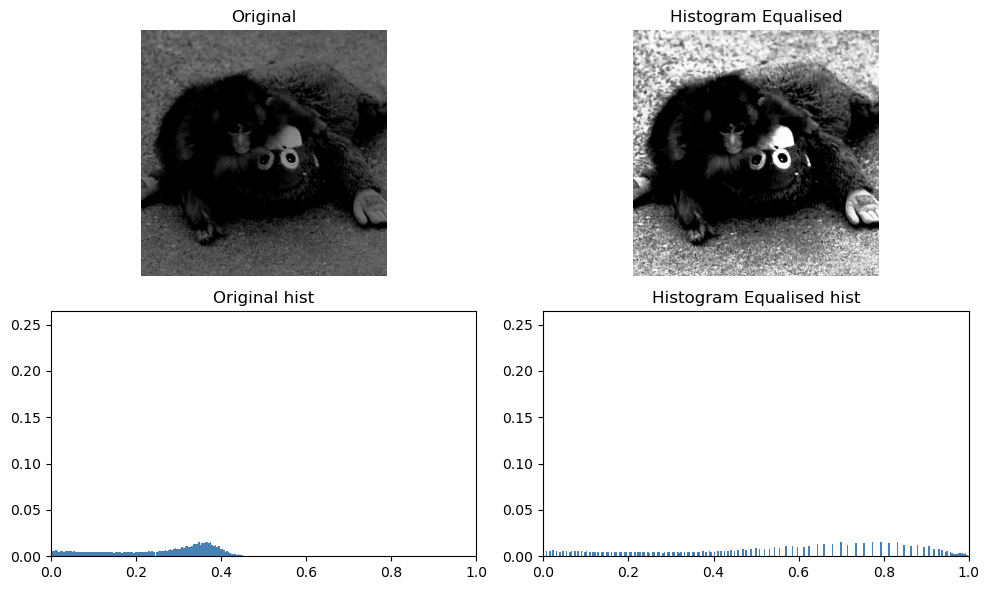

In [6]:
def hist_equalize(img_float):
    """
    Histogram equalization for a float image in [0, 1].
    Returns equalized float image in [0, 1].
    """
    img8 = (np.clip(img_float, 0, 1) * 255).astype(np.uint8)
    hist, _ = np.histogram(img8.ravel(), bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf_min = int(cdf[cdf > 0][0])
    N = img8.size

    # Build LUT
    lut = np.zeros(256, dtype=np.uint8)
    valid = cdf > 0
    lut[valid] = np.round(
        (cdf[valid] - cdf_min) / max(N - cdf_min, 1) * 255
    ).astype(np.uint8)

    equalized = lut[img8]
    return equalized.astype(np.float32) / 255.0

# Apply to a dark image
dark_img = brightness_adjust(IMG, -0.35)
dark_eq = hist_equalize(dark_img)
show_histogram_comparison(dark_img, dark_eq, mod_title="Histogram Equalised")

---
## Part 2 — Convolution Fundamentals

### 2.1 What is Convolution?

**Intuition:** slide a small window across the signal and compute a weighted average at every position.

**1-D discrete convolution:**
$$(f * g)[n] = \sum_{k} f[k]\; g[n - k]$$

**Recipe:** **Flip** the kernel, **Shift** it, **Multiply** element by element, and **Sum** the products.

### 2.2 2D Convolution

$$I'(x,y) = (I * K)(x,y) = \sum_{i=-m}^{m}\sum_{j=-n}^{n} K(i,j)\cdot I(x-i,\, y-j)$$

Each output pixel is a weighted vote of all neighbours; the weight assigned to neighbour $I(x{-}i, y{-}j)$ is $K(i,j)$.

### 2.3 Correlation vs Convolution

$$\text{Correlation:}\quad (I \star K)(x,y) = \sum_{i,j} K(i,j)\cdot I(x+i,\, y+j)$$

$$\text{Convolution:}\quad (I * K)(x,y) = \sum_{i,j} K(i,j)\cdot I(x-i,\, y-j)$$

In convolution, the kernel is **flipped** before sliding: $K_{\text{flip}}(i,j) = K(-i,-j)$.

For **symmetric** kernels (Gaussian, Laplacian) the flip has no effect: convolution = correlation.

| Property | Convolution ($*$) | Correlation ($\star$) |
|---|---|---|
| Kernel flipped? | Yes | No |
| Commutative? | Yes | No |
| Associative? | Yes | No |

> ⚠️ Many imaging libraries use *correlation* but call it "convolution".

### 2.4 Identity & Shift Filters (warm-up)

The **identity kernel** passes the image through unchanged. A shift kernel copies a neighbour's value.

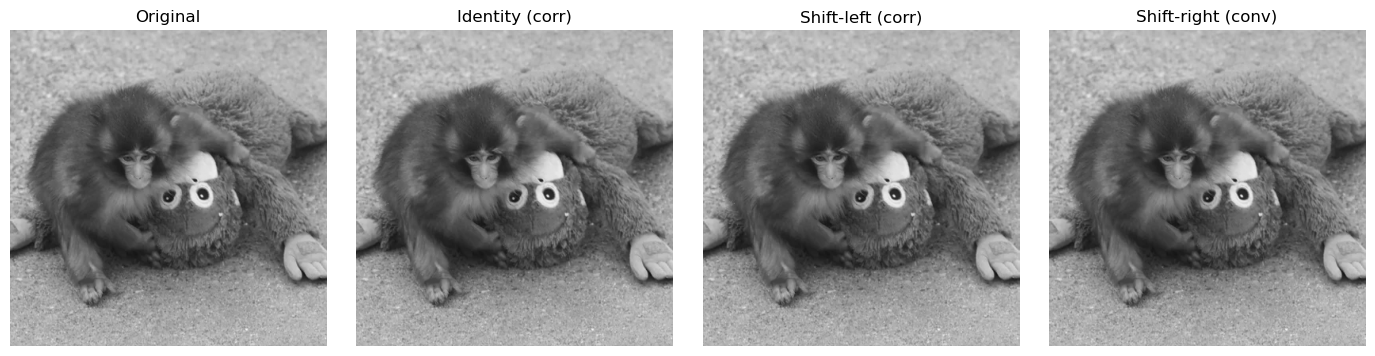

In [7]:
K_identity = np.array([[0, 0, 0],
                        [0, 1, 0],
                        [0, 0, 0]], dtype=np.float32)

# Weight on the RIGHT neighbour → under correlation, shifts LEFT
K_shift = np.array([[0, 0, 0],
                     [0, 0, 1],
                     [0, 0, 0]], dtype=np.float32)

out_id    = nd_correlate(IMG, K_identity)
out_shift = nd_correlate(IMG, K_shift)

# Convolution flips the kernel, so the same K_shift shifts RIGHT
out_conv  = nd_convolve(IMG, K_shift)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, im, t in zip(axes,
        [IMG, out_id, out_shift, out_conv],
        ["Original", "Identity (corr)", "Shift-left (corr)", "Shift-right (conv)"]):
    ax.imshow(im, cmap="gray", vmin=0, vmax=1)
    ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

### 2.5 Numerical Worked Example

**Box filter** ($1/9$) on a $3 \times 3$ patch:

$$\frac{1}{9}(10+11+10+9+10+11+10+9+10) = \frac{90}{9} = \mathbf{10}$$

In [8]:
# Reproduce the exact pixel values from the slides
pixel_grid = np.array([
    [10, 11, 10,  9, 10],
    [11, 10,  9, 10,  9],
    [ 9, 10, 11,  9,  9],
    [10,  9,  9, 11, 10],
    [10, 10,  9, 10, 10],
], dtype=np.float32)

patch = pixel_grid[1:4, 1:4]
K_box3 = np.ones((3, 3), dtype=np.float32) / 9.0

box_result = float(np.sum(patch * K_box3))
print(f"Centre 3×3 patch:\n{patch}")
print(f"\nBox filter result: {box_result:.1f}")

# Weighted ramp filter
K_ramp = np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]], dtype=np.float32) / 45.0
ramp_result = float(np.sum(patch * K_ramp))
print(f"Ramp filter result: {ramp_result:.2f}")

Centre 3×3 patch:
[[10.  9. 10.]
 [10. 11.  9.]
 [ 9.  9. 11.]]

Box filter result: 9.8
Ramp filter result: 9.76


### 2.6 Boundary Handling

When the kernel extends beyond the border, missing pixels must be filled:

| Mode | Description | Best for |
|---|---|---|
| **Zero-padding** | Missing pixels = 0 | General purpose, FFT |
| **Reflection** | Mirror across border | Smooth images |
| **Replication** | Repeat edge pixel | Preserving boundary values |
| **Wrap** | Periodic extension | Frequency-domain work |

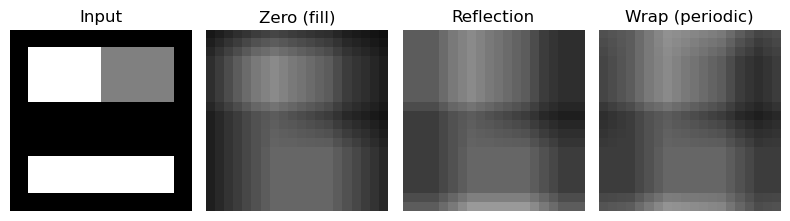

In [9]:
# Visualise boundary modes with a small test image
small = np.zeros((20, 20), dtype=np.float32)
small[2:8, 2:10] = 1.0
small[2:8, 10:18] = 0.5
small[14:18, 2:18] = 1.0

K = 10
kernel = np.ones((K,K), dtype=np.float32) / (K**2)

modes_scipy = {
    "Zero (fill)":     "fill",
    "Reflection":      "symm",
    #"Replication":     "fill",
    "Wrap (periodic)": "wrap",
}

fig, axes = plt.subplots(1, 4, figsize=(8, 3.5))
axes[0].imshow(small, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Input"); axes[0].axis("off")

for ax, (label, mode) in zip(axes[1:], modes_scipy.items()):
    out = scipy_convolve2d(small, kernel, mode="same", boundary=mode)
    ax.imshow(out, cmap="gray", vmin=0, vmax=1)
    ax.set_title(label); ax.axis("off")

# plt.suptitle("Boundary handling comparison", fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 3 — Linear Filters

A **linear filter** replaces each pixel with a *weighted sum* of its neighbourhood — this is exactly the convolution operation.

**What to look for in a kernel:**
- Entries sum to 1? → preserves mean (smoothing filter)
- Entries sum to 0? → edge detector
- Is it separable? → efficiency gain
- Is it symmetric? → convolution = correlation

### 3.1 Frequency-Domain Perspective (Convolution Theorem)

$$\mathcal{F}\{I * K\} = \mathcal{F}\{I\} \cdot \mathcal{F}\{K\}$$

Spatial-domain convolution = pointwise multiplication in Fourier domain.
A narrow kernel ↔ broad spectrum (weak filter); a wide kernel ↔ narrow spectrum (strong low-pass).

### 3.2 Box Filter (Uniform Blur)

$$K_{\text{box}} = \frac{1}{M^2}\begin{pmatrix}1&\cdots&1\\\vdots&\ddots&\vdots\\1&\cdots&1\end{pmatrix}_{M\times M}$$

- Equivalent to a **moving average**; separable.
- **Disadvantage:** rectangular window → large sidelobes in Fourier domain → ringing / Gibbs artefacts near sharp edges.

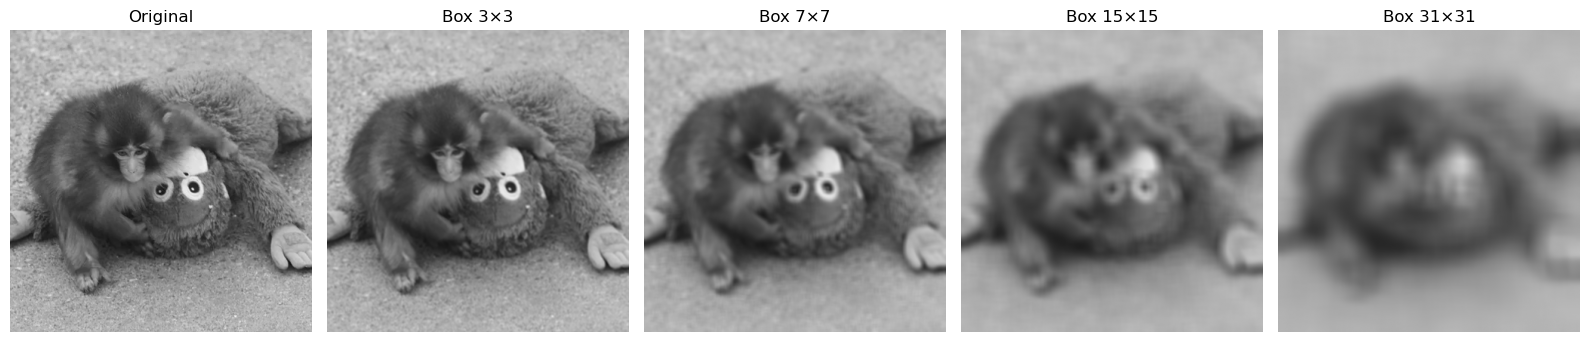

In [10]:
# Box filter at different sizes
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(IMG, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original"); axes[0].axis("off")

for ax, ks in zip(axes[1:], [3, 7, 15, 31]):
    K = box_kernel(ks)
    out = scipy_convolve2d(IMG, K, mode="same", boundary="symm")
    ax.imshow(out, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Box {ks}×{ks}"); ax.axis("off")

plt.tight_layout(); plt.show()

### 3.3 Gaussian Filter

$$K(x,y) = \frac{1}{2\pi\sigma^2}\, e^{-(x^2+y^2)/(2\sigma^2)}$$

Discretised and normalised so all entries sum to 1.

**Key properties:**
- $\sigma$ controls blur amount: larger $\sigma$ = stronger blur.
- **No sidelobes** in frequency domain → no ringing.
- **Separable**: $K(x,y) = g(x) \cdot g(y)$. Rule of thumb: kernel size $\approx 6\sigma$.

**Physical motivation:** Central Limit Theorem (sum of many small independent effects → Gaussian); defocused optics has a Gaussian PSF.

**Cascade property:** $G_{\sigma_1} * G_{\sigma_2} = G_{\sqrt{\sigma_1^2 + \sigma_2^2}}$

In [11]:
# Show the 5×5 Gaussian kernel (σ=1) — matches the lecture slide values
K_5x5 = gaussian_kernel_2d(5, 1.0)
print("5×5 Gaussian kernel (σ=1):")
print(np.round(K_5x5, 3))
print(f"Sum of entries: {K_5x5.sum():.6f}")

# Verify separability: 2D = outer product of 1D
h1d = gaussian_kernel_1d(5, 1.0)
K_outer = np.outer(h1d, h1d)
print(f"\nMax difference (2D vs outer product): {np.max(np.abs(K_5x5 - K_outer)):.2e}")

5×5 Gaussian kernel (σ=1):
[[0.003 0.013 0.022 0.013 0.003]
 [0.013 0.06  0.098 0.06  0.013]
 [0.022 0.098 0.162 0.098 0.022]
 [0.013 0.06  0.098 0.06  0.013]
 [0.003 0.013 0.022 0.013 0.003]]
Sum of entries: 1.000000

Max difference (2D vs outer product): 1.49e-08


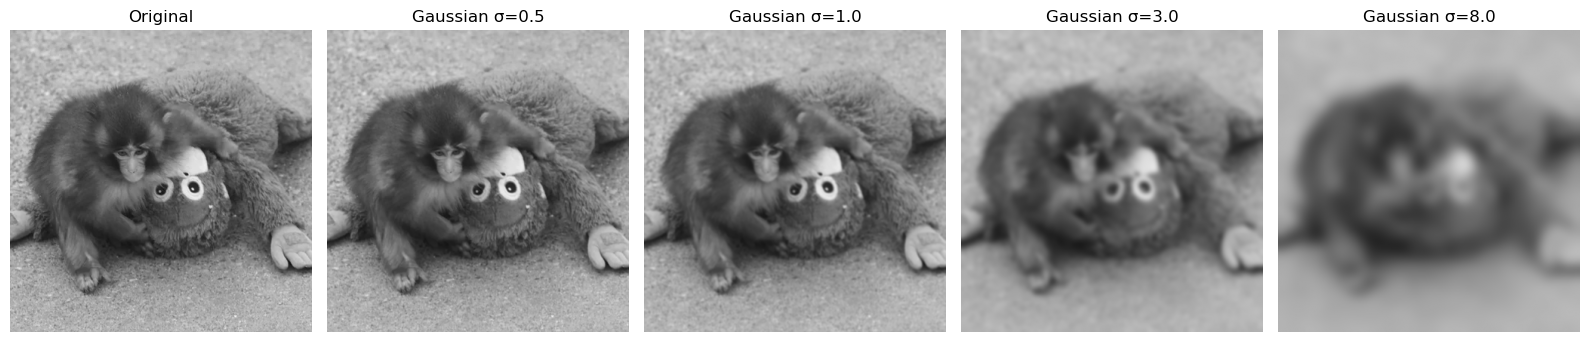

In [12]:
# Gaussian filter at different σ values
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(IMG, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original"); axes[0].axis("off")

for ax, sigma in zip(axes[1:], [0.5, 1.0, 3.0, 8.0]):
    out = gaussian_filter(IMG, sigma=sigma)
    ax.imshow(out, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Gaussian σ={sigma}"); ax.axis("off")

plt.tight_layout(); plt.show()

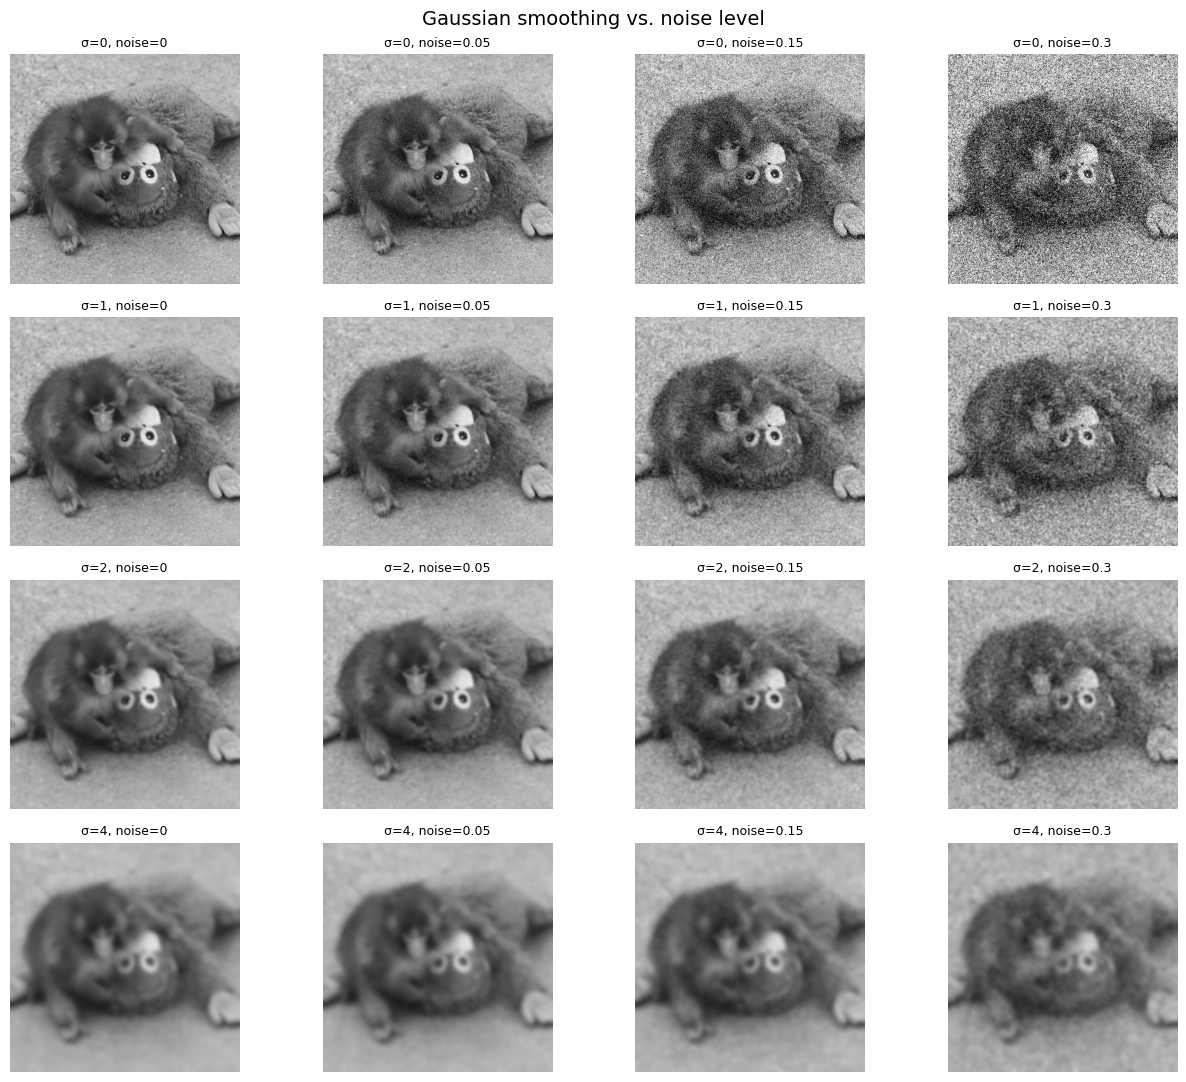

In [13]:
# σ × noise-level grid — larger σ removes noise but blurs structure
rng_sn = np.random.default_rng(7)
sigmas_grid = [0, 1, 2, 4]
noise_stds  = [0, 0.05, 0.15, 0.30]

fig, axes = plt.subplots(len(sigmas_grid), len(noise_stds), figsize=(13, 11))

for row, sigma in enumerate(sigmas_grid):
    for col, nstd in enumerate(noise_stds):
        noisy = np.clip(IMG + rng_sn.normal(0, max(nstd, 1e-9), IMG.shape).astype(np.float32), 0, 1)
        filtered = gaussian_filter(noisy, sigma=sigma) if sigma > 0 else noisy
        axes[row, col].imshow(filtered, cmap="gray", vmin=0, vmax=1)
        axes[row, col].set_title(f"σ={sigma}, noise={nstd}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Gaussian smoothing vs. noise level", fontsize=14)
plt.tight_layout(); plt.show()

---
## Part 4 — Separable Convolution

A 2-D kernel $K$ is **separable** if $K = \mathbf{h}_1 \cdot \mathbf{h}_2^\top$.

Replace one $M{\times}M$ 2-D convolution with *two* 1-D convolutions.

| | Mults/pixel | Total |
|---|---|---|
| Full 2-D | $M^2$ | $N^2 M^2$ |
| Separable | $2M$ | $2 N^2 M$ |
| **Speed-up** | $M/2$ | — |

For $M=15$: speed-up = $7.5\times$!

**Separable kernels:** Gaussian ✓, Box ✓. **Not separable:** Laplacian ✗, Median ✗.

**Test:** SVD of $K$; if rank = 1, it is separable.

In [24]:
def separable_convolve(img, h1, h2):
    """
    Separable 2-D convolution via two sequential 1-D passes.
    h1 applied along rows (axis=1), h2 applied along columns (axis=0).
    """
    H, W = img.shape
    klen = len(h1)
    pad = klen // 2

    # Pass 1: convolve each row with h1
    padded = np.pad(img, ((0, 0), (pad, pad)), mode="reflect")
    temp = np.zeros_like(img)
    for j in range(klen):
        temp += padded[:, j:j+W] * h1[j]

    # Pass 2: convolve each column with h2
    padded = np.pad(temp, ((pad, pad), (0, 0)), mode="reflect")
    out = np.zeros_like(img)
    for i in range(klen):
        out += padded[i:i+H, :] * h2[i]

    return out.astype(np.float32)

# Verify correctness
h1d = gaussian_kernel_1d(11, 2.0)
K2d = gaussian_kernel_2d(11, 2.0)

out_full = scipy_convolve2d(IMG, K2d, mode="same", boundary="symm")
out_sep  = separable_convolve(IMG, h1d, h1d)
print(f"Max difference (full vs separable): {np.max(np.abs(out_full - out_sep)):.2e}")

Max difference (full vs separable): 1.51e-02


Kernel  5× 5: full=   7.68 ms, sep=   1.38 ms, speedup=5.6×
Kernel  9× 9: full=  18.25 ms, sep=   1.10 ms, speedup=16.6×
Kernel 13×13: full=  34.89 ms, sep=   1.67 ms, speedup=20.9×
Kernel 21×21: full=  86.61 ms, sep=   2.28 ms, speedup=37.9×
Kernel 31×31: full= 215.79 ms, sep=   3.51 ms, speedup=61.5×


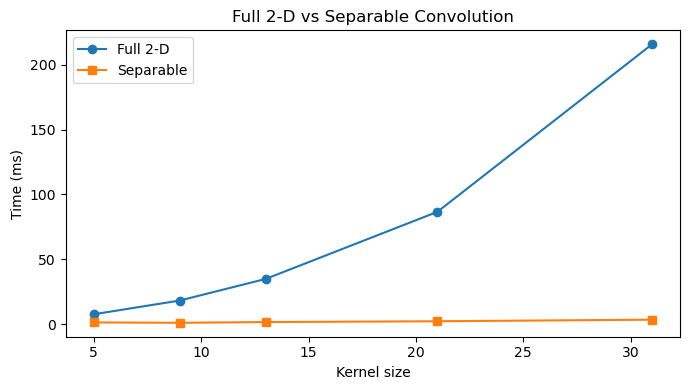

In [25]:
# Benchmark: separable vs full 2-D for different kernel sizes
sizes_bench = [5, 9, 13, 21, 31]
t_full_list, t_sep_list = [], []

for ks in sizes_bench:
    sig = ks / 6.0
    K2d = gaussian_kernel_2d(ks, sig)
    h1d = gaussian_kernel_1d(ks, sig)

    t_f = timeit.timeit(lambda K=K2d: scipy_convolve2d(IMG, K, mode="same", boundary="symm"), number=3) / 3
    t_s = timeit.timeit(lambda h=h1d: separable_convolve(IMG, h, h), number=3) / 3
    t_full_list.append(t_f)
    t_sep_list.append(t_s)
    print(f"Kernel {ks:2d}×{ks:2d}: full={t_f*1e3:7.2f} ms, sep={t_s*1e3:7.2f} ms, speedup={t_f/t_s:.1f}×")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes_bench, [t*1e3 for t in t_full_list], "o-", label="Full 2-D")
ax.plot(sizes_bench, [t*1e3 for t in t_sep_list],  "s-", label="Separable")
ax.set_xlabel("Kernel size"); ax.set_ylabel("Time (ms)")
ax.set_title("Full 2-D vs Separable Convolution"); ax.legend()
plt.tight_layout(); plt.show()

---
## Part 5 — Advanced Filters

### 5.1 Laplacian Filter (Edge Detection)

The **Laplacian** is the sum of second-order partial derivatives:

$$\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}$$

Discrete approximation:

$$K_{\text{Lap}} = \begin{pmatrix}0&-1&0\\-1&4&-1\\0&-1&0\end{pmatrix}$$

- Strong response at **edges and fine detail**. Sum of entries = 0 → zero response on flat regions.
- Highly **noise-sensitive** — always pair with Gaussian pre-smoothing.

**Laplacian sharpening:** $I_{\text{sharp}} = I - \lambda\, \nabla^2 I, \quad \lambda > 0$

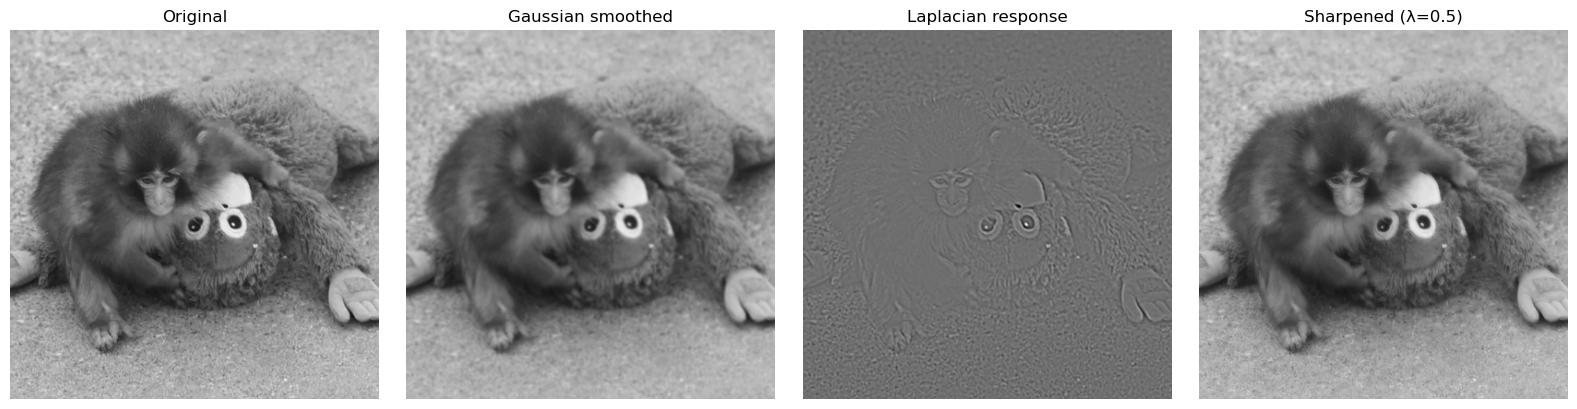

In [26]:
K_lap = np.array([[ 0, -1,  0],
                   [-1,  4, -1],
                   [ 0, -1,  0]], dtype=np.float32)

# Smooth first to reduce noise sensitivity
IMG_smooth = gaussian_filter(IMG, sigma=1.0)
lap_resp   = scipy_convolve2d(IMG_smooth, K_lap, mode="same", boundary="symm")

# Laplacian sharpening
lam = 0.5
IMG_sharp = np.clip(IMG - lam * lap_resp, 0, 1).astype(np.float32)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(IMG, cmap="gray", vmin=0, vmax=1); axes[0].set_title("Original")
axes[1].imshow(IMG_smooth, cmap="gray", vmin=0, vmax=1); axes[1].set_title("Gaussian smoothed")
axes[2].imshow(lap_resp, cmap="gray"); axes[2].set_title("Laplacian response")
axes[3].imshow(IMG_sharp, cmap="gray", vmin=0, vmax=1); axes[3].set_title(f"Sharpened (λ={lam})")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

### 5.2 Difference of Gaussians (DoG)

$$\text{DoG}_{\sigma_1,\sigma_2} = G_{\sigma_1} * I - G_{\sigma_2} * I, \quad \sigma_1 < \sigma_2$$

- **Band-pass filter** — passes spatial frequencies between the two scales.
- Approximates the **Laplacian of Gaussian** (LoG) when $\sigma_2 / \sigma_1 \approx 1.6$.
- Used in **SIFT** feature detection (Lowe, 2004).

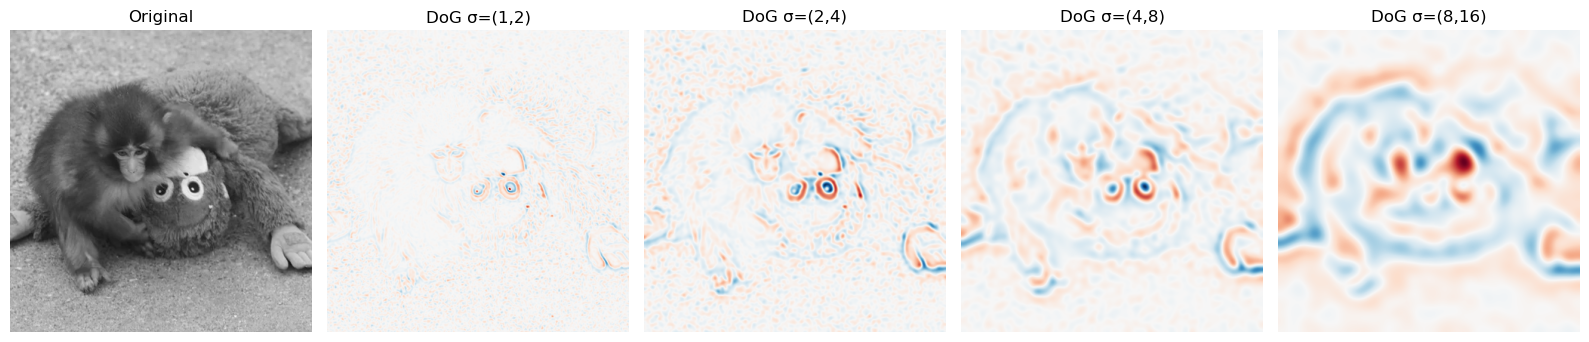

In [27]:
def dog_filter(img, sigma1, sigma2):
    """Band-pass DoG: G_sigma1 - G_sigma2 applied to img."""
    return (gaussian_filter(img, sigma=sigma1) -
            gaussian_filter(img, sigma=sigma2)).astype(np.float32)

dog_pairs = [(1, 2), (2, 4), (4, 8), (8, 16)]

fig, axes = plt.subplots(1, len(dog_pairs) + 1, figsize=(16, 3.5))
axes[0].imshow(IMG, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original"); axes[0].axis("off")

for ax, (s1, s2) in zip(axes[1:], dog_pairs):
    resp = dog_filter(IMG, s1, s2)
    v = max(abs(resp.min()), abs(resp.max()), 1e-6)
    ax.imshow(resp, cmap="RdBu_r", vmin=-v, vmax=v)
    ax.set_title(f"DoG σ=({s1},{s2})"); ax.axis("off")

plt.tight_layout(); plt.show()

### 5.3 Median Filter

Replaces each pixel with the **median** of its neighbourhood (not a weighted average).

- **Non-linear**: cannot be expressed as a convolution.
- Extremely effective for **salt-and-pepper** noise (corrupted pixels are outliers; median ignores them).
- **Edge-preserving**: median rarely crosses a strong edge.

**Example — 3×3 window:**

$$\begin{pmatrix}10&11&9\\255&10&10\\9&11&10\end{pmatrix} \quad \text{Median} = \mathbf{10}$$

The corrupted 255 is discarded. A Gaussian would give ≈38 (badly corrupted by the outlier).

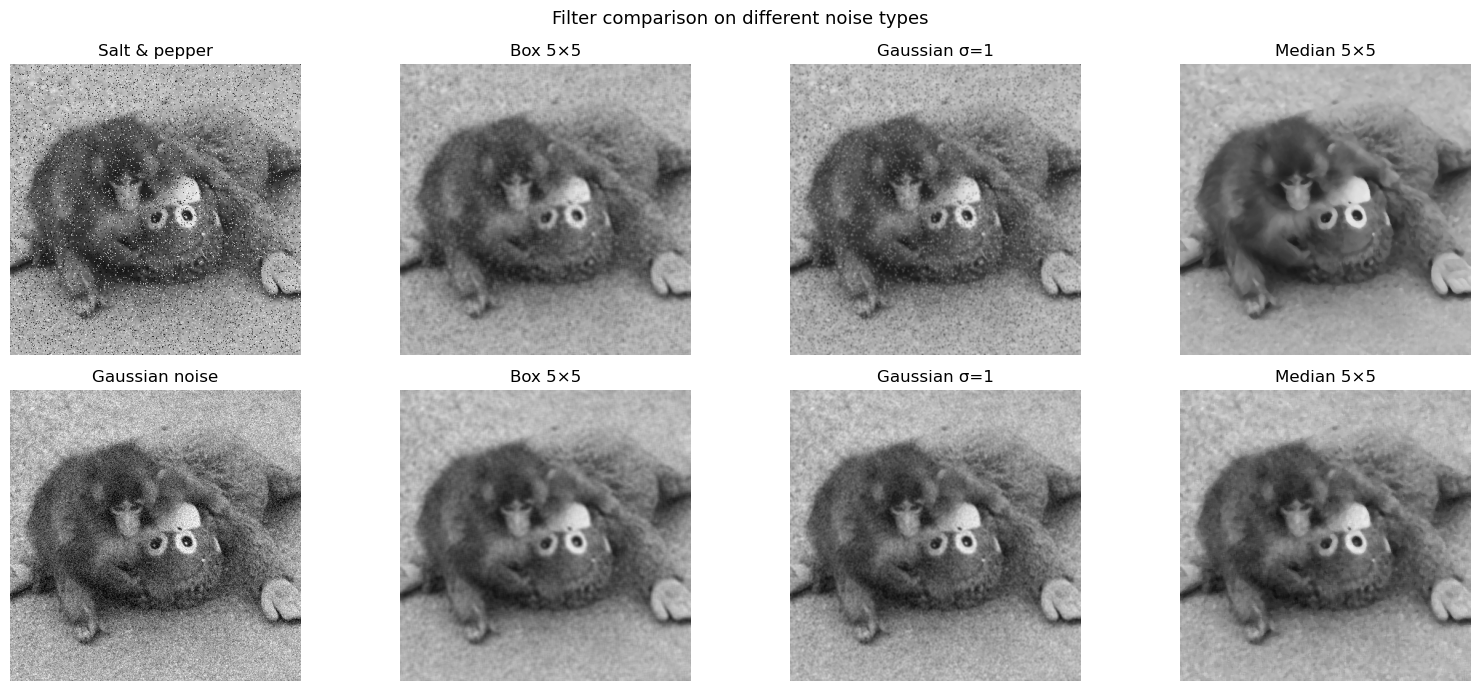

In [28]:
rng = np.random.default_rng(42)

def add_gaussian_noise(img, std=0.08):
    return np.clip(img + rng.normal(0, std, img.shape).astype(np.float32), 0, 1)

def add_salt_pepper(img, prob=0.05):
    noisy = img.copy()
    mask_s = rng.random(img.shape) < prob / 2
    mask_p = rng.random(img.shape) < prob / 2
    noisy[mask_s] = 1.0
    noisy[mask_p] = 0.0
    return noisy

IMG_GAUSS_NOISE = add_gaussian_noise(IMG, std=0.10)
IMG_SP_NOISE    = add_salt_pepper(IMG, prob=0.08)

# Compare filters on salt-and-pepper noise
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for col, (noisy, noise_name) in enumerate([(IMG_SP_NOISE, "Salt & pepper"), (IMG_GAUSS_NOISE, "Gaussian noise")]):
    row = col
    axes[row, 0].imshow(noisy, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(noise_name)

    axes[row, 1].imshow(scipy_convolve2d(noisy, box_kernel(5), mode="same", boundary="symm"),
                         cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title("Box 5×5")

    axes[row, 2].imshow(gaussian_filter(noisy, sigma=1.0), cmap="gray", vmin=0, vmax=1)
    axes[row, 2].set_title("Gaussian σ=1")

    axes[row, 3].imshow(median_filter(noisy, size=5), cmap="gray", vmin=0, vmax=1)
    axes[row, 3].set_title("Median 5×5")

for ax in axes.flat: ax.axis("off")
plt.suptitle("Filter comparison on different noise types", fontsize=13)
plt.tight_layout(); plt.show()

### 5.4 Bilateral Filter

$$I'(x,y) = \frac{1}{W_{xy}} \sum_{(i,j)\in\Omega} I(i,j)\; \underbrace{e^{-\frac{(x-i)^2+(y-j)^2}{2\sigma_s^2}}}_{w_s:\text{ spatial}} \underbrace{e^{-\frac{(I(x,y)-I(i,j))^2}{2\sigma_r^2}}}_{w_r:\text{ range}}$$

**Two weights:** one for *how close*, one for *how similar*. Average only neighbours that are both nearby in space *and* similar in intensity.

- $\sigma_s$: spatial reach. $\sigma_r$: intensity tolerance.
- **Edge-preserving:** pixels across a strong edge have very different intensities → small $w_r$ → not averaged together.
- **Non-linear** — weights depend on image content.

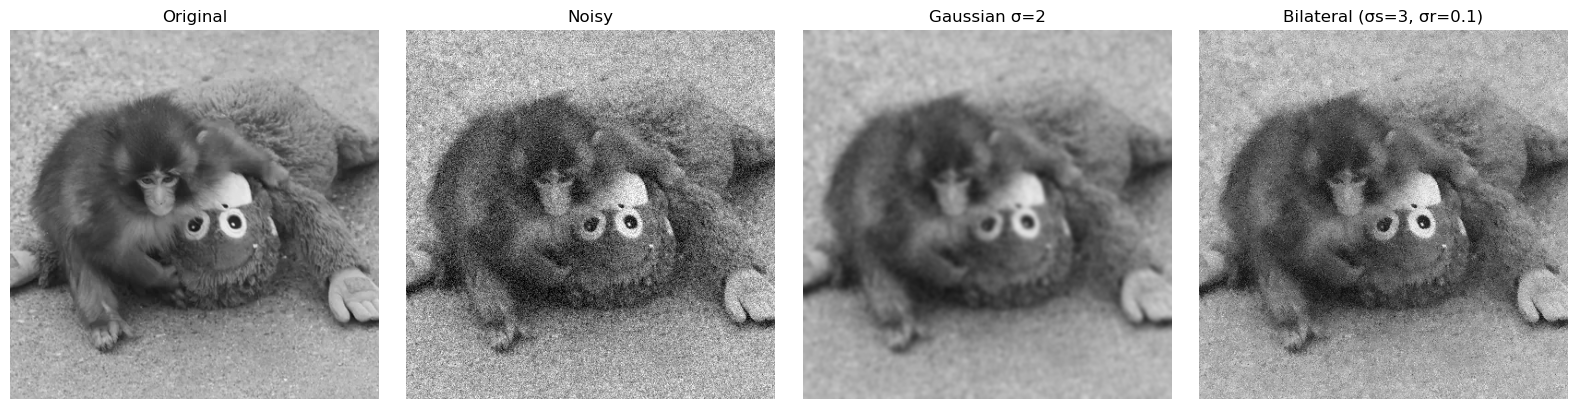

In [29]:
def bilateral_filter(img, sigma_s=3.0, sigma_r=0.1, radius=None):
    """Simple bilateral filter implementation."""
    if radius is None:
        radius = int(np.ceil(3 * sigma_s))
    H, W = img.shape
    padded = np.pad(img, radius, mode="reflect")
    out = np.zeros_like(img, dtype=np.float64)

    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            w_s = np.exp(-(dx**2 + dy**2) / (2 * sigma_s**2))
            neighbour = padded[radius+dy:radius+dy+H, radius+dx:radius+dx+W]
            w_r = np.exp(-((img - neighbour)**2) / (2 * sigma_r**2))
            w = w_s * w_r
            out += w * neighbour

    # Normalisation weight map (same loop structure)
    W_map = np.zeros_like(img, dtype=np.float64)
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            w_s = np.exp(-(dx**2 + dy**2) / (2 * sigma_s**2))
            neighbour = padded[radius+dy:radius+dy+H, radius+dx:radius+dx+W]
            w_r = np.exp(-((img - neighbour)**2) / (2 * sigma_r**2))
            W_map += w_s * w_r

    return (out / (W_map + 1e-10)).astype(np.float32)

# Compare Gaussian vs bilateral
noisy = add_gaussian_noise(IMG, std=0.10)
gauss_out = gaussian_filter(noisy, sigma=2.0)
bilat_out = bilateral_filter(noisy, sigma_s=3.0, sigma_r=0.1, radius=5)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, t in zip(axes,
        [IMG, noisy, gauss_out, bilat_out],
        ["Original", "Noisy", "Gaussian σ=2", "Bilateral (σs=3, σr=0.1)"]):
    ax.imshow(im, cmap="gray", vmin=0, vmax=1)
    ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

In [30]:
def psnr(reference, test):
    """Peak Signal-to-Noise Ratio (higher is better)."""
    mse = np.mean((reference.astype(np.float64) - test.astype(np.float64))**2)
    return float("inf") if mse == 0 else 10 * np.log10(1.0 / mse)

filter_configs = [
    ("Box 5×5",      lambda im: scipy_convolve2d(im, box_kernel(5), mode="same", boundary="symm")),
    ("Gaussian σ=1", lambda im: gaussian_filter(im, sigma=1.0)),
    ("Median 5×5",   lambda im: median_filter(im, size=5)),
]

print(f"{'Filter':<16} {'PSNR (Gauss noise)':>20} {'PSNR (S&P noise)':>20}")
print("-" * 58)
for name, fn in filter_configs:
    p_g = psnr(IMG, fn(IMG_GAUSS_NOISE))
    p_s = psnr(IMG, fn(IMG_SP_NOISE))
    print(f"{name:<16} {p_g:>18.2f} dB {p_s:>18.2f} dB")

Filter             PSNR (Gauss noise)     PSNR (S&P noise)
----------------------------------------------------------
Box 5×5                       28.97 dB              26.87 dB
Gaussian σ=1                  29.24 dB              26.08 dB
Median 5×5                    28.39 dB              31.07 dB


---
## Part 6 — Template Matching & NCC

### 6.1 Correlation as Template Matching

Correlation with filter $F$ = **dot product** between the filter vector and the image patch:

$$I'(x,y) = F \cdot \text{vec}(I_{xy}) = |F|\,|I_{xy}|\cos\theta$$

The dot product is **maximised** when the patch looks *exactly like the filter*.

### 6.2 Normalised Cross-Correlation (NCC)

$$\text{NCC}(x,y) = \frac{\sum_{i,j}\bigl(I_{xy}(i,j) - \bar{I}_{xy}\bigr)\bigl(T(i,j) - \bar{T}\bigr)}{\sqrt{\sum_{i,j}(I_{xy}(i,j) - \bar{I}_{xy})^2 \cdot \sum_{i,j}(T(i,j) - \bar{T})^2}}$$

- Range $[-1, 1]$: $+1$ = perfect match, $-1$ = perfect inverse.
- **Invariant** to additive and multiplicative intensity changes.
- Complexity: $O(H \cdot W \cdot t_H \cdot t_W)$; FFT acceleration: $O(HW\log HW)$.

**Limitations:** not invariant to rotation, scale, or viewpoint; degrades with partial occlusion.

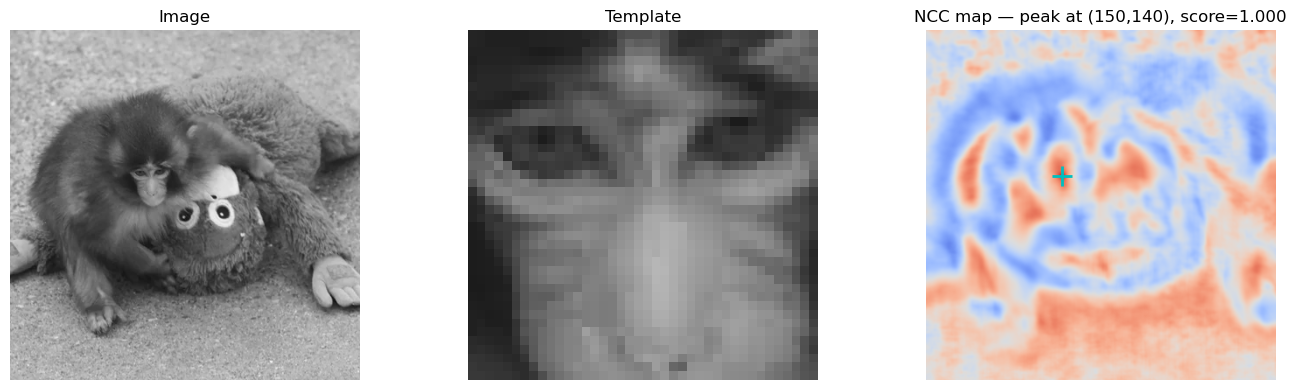

In [31]:
def ncc_match(img, template):
    """
    Normalised Cross-Correlation — vectorised over patches.
    Returns NCC map of shape (H - tH + 1, W - tW + 1) in [-1, 1].
    """
    tH, tW = template.shape
    T = template - template.mean()
    T_norm = float(np.sqrt(np.sum(T**2))) + 1e-8

    patches = sliding_window_view(img, (tH, tW))
    out_H, out_W = patches.shape[:2]
    patches_flat = patches.reshape(out_H, out_W, -1).astype(np.float64)

    P_mean = patches_flat.mean(axis=2, keepdims=True)
    P_cent = patches_flat - P_mean
    P_norm = np.sqrt(np.sum(P_cent**2, axis=2)) + 1e-8

    T_flat = T.ravel().astype(np.float64)
    ncc = np.sum(P_cent * T_flat[None, None, :], axis=2) / (P_norm * T_norm)
    return ncc.astype(np.float32)

# Extract a template and find it
r0, c0, tH, tW = 150, 140, 40, 40
template = IMG[r0:r0+tH, c0:c0+tW].copy()

ncc_map = ncc_match(IMG, template)
peak_r, peak_c = np.unravel_index(ncc_map.argmax(), ncc_map.shape)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(IMG, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Image"); axes[0].axis("off")

axes[1].imshow(template, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Template"); axes[1].axis("off")

axes[2].imshow(ncc_map, cmap="coolwarm",vmin=-1,vmax=1)
axes[2].plot(peak_c, peak_r, "c+", markersize=15, markeredgewidth=2)
axes[2].set_title(f"NCC map — peak at ({peak_r},{peak_c}), score={ncc_map.max():.3f}")
axes[2].axis("off")
plt.tight_layout(); plt.show()

### 6.3 NCC: $\sigma_I / \sigma_T$ Formulation

Equivalent expression that makes the invariances explicit:

$$\text{NCC}(u, v) = \frac{1}{N} \sum_{x,y} \frac{(I(u+x, v+y) - \bar{I}_{u,v})(T(x, y) - \bar{T})}{\sigma_{I_{u,v}}\, \sigma_T}$$

**Two explicit invariances:**
1. **Additive invariance** — subtracting the mean removes DC offset (bias lighting, background level).
2. **Multiplicative invariance** — dividing by $\sigma$ removes gain (exposure level, reflectance scale).

In [32]:
def ncc_sigma_formulation(img, template):
    """NCC using the σ_I / σ_T formulation."""
    tH, tW = template.shape
    T_mean = template.mean()
    T_std  = template.std() + 1e-8
    T_cent = template - T_mean

    patches = sliding_window_view(img, (tH, tW))
    out_H, out_W = patches.shape[:2]
    patches_flat = patches.reshape(out_H, out_W, -1).astype(np.float64)

    P_mean = patches_flat.mean(axis=2, keepdims=True)
    P_std  = patches_flat.std(axis=2) + 1e-8
    P_cent = patches_flat - P_mean

    T_flat = T_cent.ravel().astype(np.float64)
    n = tH * tW
    ncc = np.sum(P_cent * T_flat[None, None, :], axis=2) / (n * P_std * T_std)
    return ncc.astype(np.float32)

# Verify both formulations agree
ncc_a = ncc_match(IMG, template)
ncc_b = ncc_sigma_formulation(IMG, template)
print(f"Max difference between formulations: {np.max(np.abs(ncc_a - ncc_b)):.2e}")

Max difference between formulations: 2.38e-07


### 6.4 Gaussian Pyramids for Multi-Scale Matching

When finding objects, we don't know what size they'll be. Template size is constant, but image size changes.

**Strategy:** build a Gaussian pyramid (smooth + downsample 2× per level), apply NCC at each level.

**Complexity:** geometric series → all extra pyramid levels add only $\frac{1}{3}$ more work:
$$N^2\left(1 + \frac{1}{4} + \frac{1}{16} + \cdots\right) = \frac{4}{3}N^2$$

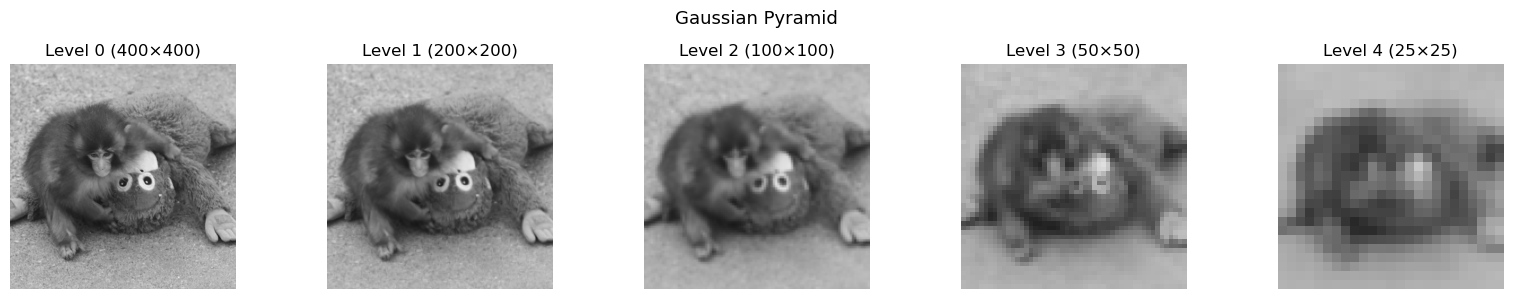

In [33]:
def build_gaussian_pyramid(img, n_levels=4, sigma=1.0):
    """Build a Gaussian pyramid: smooth + downsample 2× per level."""
    pyr = [img.copy()]
    for _ in range(n_levels - 1):
        pyr.append(gaussian_filter(pyr[-1], sigma=sigma)[::2, ::2])
    return pyr

pyramid = build_gaussian_pyramid(IMG, n_levels=5)

fig, axes = plt.subplots(1, len(pyramid), figsize=(16, 3))
for i, (ax, level) in enumerate(zip(axes, pyramid)):
    ax.imshow(level, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Level {i} ({level.shape[0]}×{level.shape[1]})")
    ax.axis("off")
plt.suptitle("Gaussian Pyramid", fontsize=13)
plt.tight_layout(); plt.show()

---
## Lecture Summary

| Topic | Key Take-away |
|---|---|
| Brightness / Contrast | Additive / multiplicative point ops; always clip. |
| Normalisation | Stretch histogram to full $[0,1]$. |
| Gamma correction | Power law; $\gamma < 1$ brightens (sRGB $\gamma = 1/2.2$). |
| Histogram equalisation | Linearises CDF; can over-enhance noise. |
| Convolution vs Correlation | Conv flips kernel; identical for symmetric kernels. |
| Boundary handling | Zero-pad / reflect / replicate — choice matters at borders. |
| Box filter | Moving average; Gibbs ringing; $O(1)$ sliding-sum. |
| Gaussian filter | No ringing; controlled by $\sigma$; separable. |
| Laplacian / DoG | Edges; zero DC; noise-sensitive; SIFT foundation. |
| Median filter | Best for salt & pepper; edge-preserving; non-linear. |
| Bilateral filter | Spatial + range weights; edge-preserving denoising. |
| Separable conv. | Rank-1 kernel → $M/2\times$ speed-up. |
| NCC template matching | Score ∈ $[-1,1]$; intensity-invariant; FFT-accelerable. |

### Connections to Medical Imaging
- **Windowing:** CT DICOM viewers map Hounsfield units via window/level point operation.
- **Histogram equalisation:** chest X-ray enhancement — apply carefully to avoid noise amplification.
- **Gaussian pre-filtering:** anti-aliasing before MRI reconstruction; scale-space analysis for lesion detection.
- **Bilateral / NLM denoising:** preserves thin structures (vessels, sulci) while smoothing.
- **Template matching:** microscopy cell counting, cardiac landmark detection, surgical tool tracking.

---
### References
1. Gonzalez, R.C. & Woods, R.E. (2018). *Digital Image Processing* (4th ed.). Pearson.
2. Burger, W. & Burge, M. (2016). *Digital Image Processing: An Algorithmic Introduction Using Java* (2nd ed.). Springer.